In [1]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

from abc import ABC, abstractmethod


class IFaceSegmenter(ABC):

    @abstractmethod
    def segment(self, image: np.ndarray):
        pass



class SegFormerB5FaceSegmenter(IFaceSegmenter):
    """
    Face parser using SegFormer MIT-B5 pretrained on CelebAMask-HQ.
    Model: jonathandinu/face-parsing
    """

    def __init__(self, device=None):
        self.device = device or (
            "cuda" if torch.cuda.is_available()
            else "mps" if torch.backends.mps.is_available()
            else "cpu"
        )

        self.processor = SegformerImageProcessor.from_pretrained(
            "jonathandinu/face-parsing"
        )
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            "jonathandinu/face-parsing"
        ).to(self.device)
        self.model.eval()

        # label ids chứa vùng mặt
        self.face_ids = {1,2,3,4,5,6,7,8,9,10,11,12,13}
        # self.face_ids = {1,2,3,4,5,6,7,8,9,10,11,12}


    # ============================================================
    #                   HELPER FUNCTIONS
    # ============================================================

    @staticmethod
    def extract_face_bbox(face_mask: np.ndarray):
        """
        Input:
            face_mask shape (H, W) with values 0 or 255

        Output:
            bbox = (x1, y1, x2, y2)
        """
        ys, xs = np.where(face_mask > 0)
        if len(xs) == 0:
            return None  # Không thấy mặt

        x1, y1 = xs.min(), ys.min()
        x2, y2 = xs.max(), ys.max()

        return (x1, y1, x2, y2)

    @staticmethod
    def crop_face_by_bbox(image: np.ndarray, bbox):
        """
        image: np.ndarray (H, W, 3)
        bbox: (x1, y1, x2, y2)

        return cropped_face (np.ndarray)
        """
        if bbox is None:
            return None

        x1, y1, x2, y2 = bbox
        return image[y1:y2, x1:x2]

    # ============================================================
    #                     SEGMENT FUNCTION
    # ============================================================

    def segment(self, image: np.ndarray):
        """
        Return:
            face_mask   - uint8 mask (0/255)
            face_region - masked face (same size as input)
            bbox        - (x1, y1, x2, y2)
            face_crop   - cropped using bbox
        """
        if isinstance(image, np.ndarray):
            pil_image = Image.fromarray(image)
        else:
            raise ValueError("image must be numpy array")

        H, W = image.shape[:2]

        # preprocess
        inputs = self.processor(images=pil_image, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits

        # resize segmentation output
        upsampled = nn.functional.interpolate(
            logits, size=(H, W), mode='bilinear', align_corners=False
        )
        labels = upsampled.argmax(dim=1)[0].cpu().numpy()

        # mask
        face_mask = (np.isin(labels, list(self.face_ids)).astype(np.uint8) * 255)

        # region (same size as image)
        face_mask_3 = np.stack([face_mask]*3, axis=-1)
        face_region = image * (face_mask_3 > 0)

        # ---- NEW: compute bbox ----
        bbox = self.extract_face_bbox(face_mask)

        # ---- NEW: get cropped region ----
        face_crop = self.crop_face_by_bbox(face_region, bbox)

        return face_mask, face_region, bbox, face_crop


    # ============================================================
    #                     APPLY FACE TO BODY
    # ============================================================

    @classmethod
    def apply_to_body(self, body_image: np.ndarray, face_region: np.ndarray,
                      anchor_point = (360, 20), face_scale = (360, 360)):

        body_pil = Image.fromarray(body_image).convert("RGBA")
        face_pil = Image.fromarray(face_region).convert("RGBA")

        # Resize face by user request
        face_pil = face_pil.resize(face_scale, Image.LANCZOS)

        # Build alpha from non-black pixels
        face_np = np.array(face_region)
        alpha_mask = (np.any(face_np > 0, axis=-1).astype(np.uint8) * 255)
        alpha_mask = Image.fromarray(alpha_mask).resize(face_scale)
        face_pil.putalpha(alpha_mask)

        face_w, face_h = face_pil.size
        ax, ay = anchor_point

        # center-anchor
        tx = ax - face_w // 2
        ty = ay - face_h // 2

        # expand canvas if needed
        pad_left   = max(0, -tx)
        pad_top    = max(0, -ty)
        pad_right  = max(0, tx + face_w - body_pil.width)
        pad_bottom = max(0, ty + face_h - body_pil.height)

        if any([pad_left, pad_top, pad_right, pad_bottom]):
            new_w = body_pil.width + pad_left + pad_right
            new_h = body_pil.height + pad_top + pad_bottom
            canvas = Image.new("RGBA", (new_w, new_h), (255,255,255,0))
            canvas.paste(body_pil, (pad_left, pad_top))
            body_pil = canvas
            tx += pad_left
            ty += pad_top

        body_pil.paste(face_pil, (tx, ty), face_pil)

        return np.array(body_pil.convert("RGB"))


/home/anhndt/miniconda3/envs/openmmlab/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


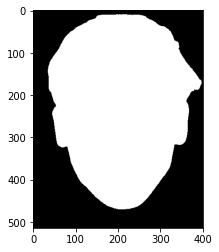

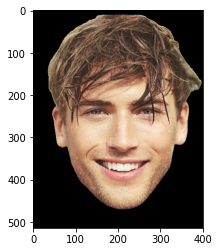

In [6]:
import matplotlib.pyplot as plt

segmenter = SegFormerB5FaceSegmenter()

img = np.array(Image.open("/home/anhndt/animating_image/src/configs/characters/face/face_01.png").convert("RGB"))


face_mask, face_region, bbox, face_crop = segmenter.segment(img)

plt.imshow(face_mask, cmap="gray")
plt.show()

plt.imshow(face_region)
plt.show()

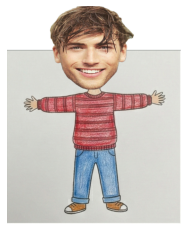

In [7]:
body = np.array(Image.open("/home/anhndt/animating_image/src/configs/characters/cartoon_body/2.png").convert("RGB"))

output = SegFormerB5FaceSegmenter.apply_to_body(body, face_crop, anchor_point = (365, -10))

plt.imshow(output)
plt.axis("off")
plt.show()

In [ ]:
C = 10

In [1]:
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor




class SegFormerB5FaceSegmenter:
    """
    Face parser using SegFormer MIT-B5 pretrained on CelebAMask-HQ.
    Model: jonathandinu/face-parsing
    """

    def __init__(self, device=None):
        self.device = device or (
            "cuda"
            if torch.cuda.is_available()
            else "mps"
            if torch.backends.mps.is_available()
            else "cpu"
        )

        self.processor = SegformerImageProcessor.from_pretrained(
            "jonathandinu/face-parsing"
        )
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            "jonathandinu/face-parsing"
        ).to(self.device)
        self.model.eval()

        self.face_ids = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13}

    # ============================================================
    #                   HELPER FUNCTIONS
    # ============================================================

    @staticmethod
    def extract_face_bbox(face_mask: np.ndarray):
        """
        Input:
            face_mask shape (H, W) with values 0 or 255

        Output:
            bbox = (x1, y1, x2, y2)
        """
        ys, xs = np.where(face_mask > 0)
        if len(xs) == 0:
            return None 

        x1, y1 = xs.min(), ys.min()
        x2, y2 = xs.max(), ys.max()

        return (x1, y1, x2, y2)

    @staticmethod
    def crop_face_by_bbox(image: np.ndarray, bbox):
        """
        image: np.ndarray (H, W, 3)
        bbox: (x1, y1, x2, y2)

        return cropped_face (np.ndarray)
        """
        if bbox is None:
            return None

        x1, y1, x2, y2 = bbox
        return image[y1:y2, x1:x2]

    # ============================================================
    #                     SEGMENT FUNCTION
    # ============================================================

    def segment(self, image: np.ndarray):
        """
        Return:
            face_mask   - uint8 mask (0/255)
            face_region - masked face (same size as input)
            bbox        - (x1, y1, x2, y2)
            face_crop   - cropped using bbox
        """
        if isinstance(image, np.ndarray):
            pil_image = Image.fromarray(image)
        else:
            raise ValueError("image must be numpy array")

        H, W = image.shape[:2]

        # preprocess
        inputs = self.processor(
            images=pil_image, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits

        # resize segmentation output
        upsampled = nn.functional.interpolate(
            logits, size=(H, W), mode="bilinear", align_corners=False
        )
        labels = upsampled.argmax(dim=1)[0].cpu().numpy()

        # mask
        face_mask = np.isin(labels, list(self.face_ids)).astype(np.uint8) * 255

        # region (same size as image)
        face_mask_3 = np.stack([face_mask] * 3, axis=-1)
        face_region = image * (face_mask_3 > 0)

        # ---- NEW: compute bbox ----
        bbox = self.extract_face_bbox(face_mask)

        # ---- NEW: get cropped region ----
        face_crop = self.crop_face_by_bbox(face_region, bbox)

        return face_mask, face_region, bbox, face_crop

    # ============================================================
    #                     APPLY FACE TO BODY
    # ============================================================

    def apply_to_body(
        self,
        body_image: np.ndarray,
        face_region: np.ndarray,
        face_scale=(256, 256),
        body_scale=(512, 768),
        x_offset: int = 5,
        y_offset: int = 20
    ):
        body_pil = Image.fromarray(body_image).convert("RGBA")
        face_pil = Image.fromarray(face_region).convert("RGBA")

        # --- scale images ---
        body_pil = body_pil.resize(body_scale, Image.LANCZOS)
        face_pil = face_pil.resize(face_scale, Image.LANCZOS)

        # --- detect alpha for head ---
        face_np = np.array(face_region)
        alpha_mask = np.any(face_np > 0, axis=-1).astype(np.uint8) * 255
        alpha_mask = Image.fromarray(alpha_mask).resize(face_scale)
        face_pil.putalpha(alpha_mask)

        face_w, face_h = face_pil.size

        # ========== AUTO FIND HEAD ANCHOR ==========
        body_np = np.array(body_pil)

        # find first non-white pixel along height
        # (body likely has white background)
        ys = np.where(np.any(body_np < 250, axis=-1))[0]   # tolerance
        if len(ys) == 0:
            first_pixel_y = body_scale[1] // 4             # fallback
        else:
            first_pixel_y = ys[0]

        # center x
        ax = body_scale[0] // 2 - x_offset

        # align head so chin touches detected pixel
        ay = first_pixel_y - face_h // 2 + y_offset

        # ====================================================================

        tx = ax - face_w // 2
        ty = ay - face_h // 2

        # expand canvas if head goes out-of-bound
        pad_left = max(0, -tx)
        pad_top = max(0, -ty)
        pad_right = max(0, tx + face_w - body_pil.width)
        pad_bottom = max(0, ty + face_h - body_pil.height)

        if any([pad_left, pad_top, pad_right, pad_bottom]):
            new_w = body_pil.width + pad_left + pad_right
            new_h = body_pil.height + pad_top + pad_bottom
            canvas = Image.new("RGBA", (new_w, new_h), (255, 255, 255, 0))
            canvas.paste(body_pil, (pad_left, pad_top))
            body_pil = canvas
            tx += pad_left
            ty += pad_top

        body_pil.paste(face_pil, (tx, ty), face_pil)

        return np.array(body_pil.convert("RGB"))



/home/anhndt/miniconda3/envs/openmmlab/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
face_segment = SegFormerB5FaceSegmenter("cuda")

In [3]:
image = Image.open("/mnt/mmlab2024nas/anhndt/animated_drawings/static/characters/0c9402f2-4065-4785-8540-b76a7e9f1786/face_region.png").convert("RGB")
body = Image.open("/home/anhndt/animating_image/src/configs/new_body/2.png")
image = np.array(image)
body = np.array(body)

In [4]:
body.shape

(2954, 2048, 4)

In [5]:
face_mask, face_region, bbox, face_crop = face_segment.segment(image)

In [6]:
res = face_segment.apply_to_body(body, face_crop)

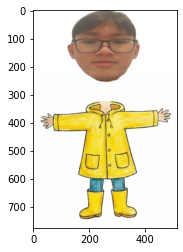

In [7]:
import matplotlib.pyplot as plt

plt.imshow(res)
plt.show()

In [9]:
from PIL import Image

def convert_background_to_white(input_file, output_file):
    """
    Chuyển đổi nền của ảnh thành màu trắng.

    Args:
        input_file (str): Đường dẫn đến tệp ảnh đầu vào.
        output_file (str): Đường dẫn đến tệp ảnh đầu ra.
    """
    try:
        img = Image.open(input_file)
        img = img.convert("RGBA")  # Đảm bảo ảnh có kênh alpha

        datas = img.getdata()

        new_datas = []
        for item in datas:
            # Nếu pixel gần như trong suốt (kênh alpha nhỏ), thì chuyển thành trắng hoàn toàn.
            # Bạn có thể điều chỉnh ngưỡng 10 tùy theo nhu cầu.
            if item[3] < 50:  # Kênh alpha (độ trong suốt)
                new_datas.append((255, 255, 255, 255))  # Màu trắng hoàn toàn, không trong suốt
            else:
                new_datas.append(item)

        img.putdata(new_datas)
        img.save(output_file)
        print(f"Đã chuyển đổi nền ảnh và lưu vào: {output_file}")

    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy tệp ảnh đầu vào tại '{input_file}'")
    except Exception as e:
        print(f"Đã xảy ra lỗi: {e}")

# Ví dụ sử dụng:
# Giả sử bạn có một ảnh tên là 'input.png'
# convert_background_to_white('input.png', 'output_white_bg.png')

In [10]:
i = "/home/anhndt/animating_image/src/configs/body/2-removebg-preview.png"
o = "/home/anhndt/animating_image/src/configs/body_with_background/2.png"
convert_background_to_white(i, o)

Đã chuyển đổi nền ảnh và lưu vào: /home/anhndt/animating_image/src/configs/body_with_background/2.png
